## demo1: Download the list of profiles and filter them using the point-in-polygon algorithm

This demo illustrates how to:

1. Load the global Argo profile index.
2. Define a geographic polygon (e.g., Mexico's Exclusive Economic Zone).
3. Apply a vectorized point-in-polygon filter.
4. Visualize the selected profiles on a map.

In [1]:
import pandas as pd
import cluster_qc

In [2]:
# directory = pd.read_csv('ftp://ftp.ifremer.fr/ifremer/argo/ar_index_global_prof.txt', skiprows=8).dropna()
directory = pd.read_csv('C:/bd/argo/202406-ArgoData/dac/ar_index_global_prof.txt', skiprows=8).dropna()
directory

,file,date,latitude,longitude,ocean,profiler_type,institution,date_update
0,aoml/13857/profiles/R13857_001.nc,1.997073e+13,0.267,-16.032,A,845,AO,20181011180520
1,aoml/13857/profiles/R13857_002.nc,1.997081e+13,0.072,-17.659,A,845,AO,20181011180521
2,aoml/13857/profiles/R13857_003.nc,1.997082e+13,0.543,-19.622,A,845,AO,20181011180521
3,aoml/13857/profiles/R13857_004.nc,1.997083e+13,1.256,-20.521,A,845,AO,20181011180521
4,aoml/13857/profiles/R13857_005.nc,1.997091e+13,0.720,-20.768,A,845,AO,20181011180521
...,...,...,...,...,...,...,...,...
2984596,nmdis/2901633/profiles/R2901633_067.nc,2.013050e+13,27.462,139.107,P,841,NM,20130507103443
2984597,nmdis/2901633/profiles/R2901633_068.nc,2.013051e+13,27.432,138.840,P,841,NM,20130511165723
2984598,nmdis/2901633/profiles/R2901633_069.nc,2.013052e+13,27.692,138.677,P,841,NM,20130521170139
2984599,nmdis/2901633/profiles/R2901633_070.nc,2.013053e+13,27.895,138.465,P,841,NM,20130531181516


In [3]:
polygon = pd.read_csv("data/eez_of_mexico.csv", usecols=['latitude','longitude'])
polygon

,latitude,longitude
0,32.718729,-114.720171
1,32.536890,-117.121976
2,32.536669,-117.124387
3,32.536379,-117.142797
4,32.569291,-117.142652
...,...,...
354,25.604513,-93.442435
355,25.980680,-93.397574
356,25.972327,-95.615069
357,25.950305,-97.138761


,file,date,latitude,longitude,ocean,profiler_type,institution,date_update
36,aoml/1902272/profiles/R1902272_017.nc,2.022041e+13,12.804,-98.914,P,863,AO,20220407090114
37,aoml/1902272/profiles/R1902272_018.nc,2.022042e+13,13.214,-98.838,P,863,AO,20220417090121
38,aoml/1902272/profiles/R1902272_019.nc,2.022043e+13,13.079,-98.903,P,863,AO,20220517090145
42,aoml/1902272/profiles/R1902272_023.nc,2.022061e+13,12.617,-98.139,P,863,AO,20220606090152
43,aoml/1902272/profiles/R1902272_024.nc,2.022062e+13,12.598,-97.812,P,863,AO,20220616070124
...,...,...,...,...,...,...,...,...
43751,meds/4902475/profiles/R4902475_180.nc,2.024042e+13,22.282,-111.119,P,844,ME,20240422191552
43752,meds/4902475/profiles/R4902475_181.nc,2.024050e+13,22.723,-111.236,P,844,ME,20240503011550
43753,meds/4902475/profiles/R4902475_182.nc,2.024051e+13,22.969,-111.542,P,844,ME,20240513131558
43754,meds/4902475/profiles/R4902475_183.nc,2.024052e+13,23.240,-111.777,P,844,ME,20240523101549


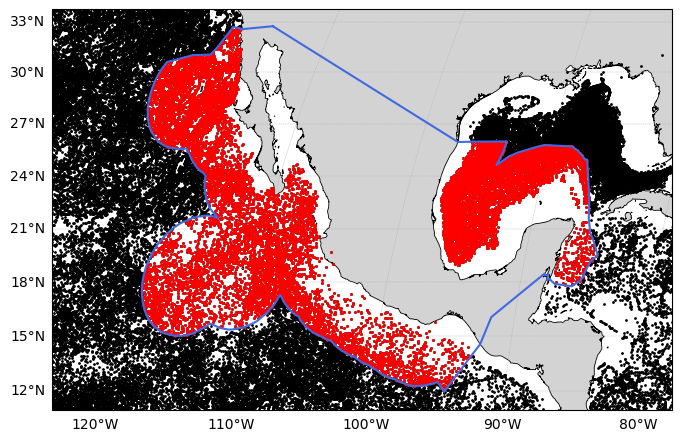

In [4]:
df, fig = cluster_qc.get_profiles_within_polygon(directory, polygon, storage_path="./data")
df